In [1]:
import torch
import torch.nn as nn
import numpy as np
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from math import log
from scipy.stats import pearsonr

In [2]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


## Training of Tranformer Model

In [3]:
# Load dataset from our file
fulldata = np.load("fulldataset.npz")
X = fulldata["X"]
y = fulldata["Y"]

short_X = X[:5000,:,:]
short_y = y[:5000,:,:]


In [4]:
y = y.mean(axis=2)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size  = 0.2)
print(X_train.shape, X_val.shape, y_train.shape, y_val.shape)

(47656, 4, 2000) (11914, 4, 2000) (47656, 64) (11914, 64)


In [5]:
# truncated dataset to speed up early training
short_y = short_y.mean(axis=2)
short_X_train, short_X_val, short_y_train, short_y_val = train_test_split(short_X, short_y, test_size  = 0.2)
print(short_X_train.shape, short_X_val.shape, short_y_train.shape, short_y_val.shape)

(4000, 4, 2000) (1000, 4, 2000) (4000, 64) (1000, 64)


In [6]:
def get_dataloaders(X, Y):
    X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.25, random_state=42)
    
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
    X_test_tensor  = torch.tensor(X_test,  dtype=torch.float32)
    y_test_tensor  = torch.tensor(y_test,  dtype=torch.float32)

    train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=32, shuffle=True)
    test_loader  = DataLoader(TensorDataset(X_test_tensor,  y_test_tensor),  batch_size=32, shuffle=False)
    return train_loader, test_loader

In [7]:
class ConvBlock(nn.Module):
    def __init__(self, num_kernels=[32, 64, 128], kernel_size=12):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv1d(in_channels=4, out_channels=num_kernels[0], kernel_size=kernel_size),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(in_channels=num_kernels[0], out_channels=num_kernels[1], kernel_size=kernel_size),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(in_channels=num_kernels[1], out_channels=num_kernels[2], kernel_size=kernel_size),
            nn.ReLU(),
        )

    def forward(self, x):
        # x: (batch, 4, seq_len) → (batch, num_kernels[-1], compressed_len)
        return self.conv_block(x)


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_seq_length=2000):
        super().__init__()
        pe = torch.zeros(max_seq_length, d_model)
        position = torch.arange(0, max_seq_length, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        # x: (batch, seq_len, d_model)
        return x + self.pe[:, :x.size(1), :].to(x.dtype)


class FeedForward(nn.Module):
    def __init__(self, d_model, dim_feedforward, dropout=0.1):
        super().__init__()
        self.linear1 = nn.Linear(d_model, dim_feedforward)
        self.linear2 = nn.Linear(dim_feedforward, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.linear2(self.dropout(F.relu(self.linear1(x))))


class EncoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, dim_feedforward=512, dropout=0.1):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(d_model, num_heads, dropout=dropout, batch_first=True)
        self.ff = FeedForward(d_model, dim_feedforward, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # Pre-LN bidirectional attention (no causal mask — correct for regression)
        normed = self.norm1(x)
        attn_out, _ = self.self_attn(normed, normed, normed)
        x = x + self.dropout(attn_out)
        x = x + self.dropout(self.ff(self.norm2(x)))
        return x


class Transformer(nn.Module):
    def __init__(
        self,
        num_kernels=[32, 64, 128],  # Conv filter counts
        kernel_size=12,             # Conv kernel size
        d_model=128,                # Transformer hidden dim (must match num_kernels[-1])
        num_heads=4,                # Attention heads (must divide d_model)
        num_layers=4,               # Number of transformer blocks
        dim_feedforward=256,        # FFN inner dim
        dropout=0.1,
        n_outputs=64,                # Number of regression targets
    ):
        super().__init__()

        assert num_kernels[-1] == d_model, (
            f"num_kernels[-1] ({num_kernels[-1]}) must equal d_model ({d_model}) "
            f"so conv output can feed directly into the transformer."
        )

        self.conv = ConvBlock(num_kernels, kernel_size)
        self.pos_enc = PositionalEncoding(d_model)
        self.encoder_blocks = nn.ModuleList([
            EncoderBlock(d_model, num_heads, dim_feedforward, dropout)
            for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Sequential(
            nn.Linear(d_model, n_outputs),
            nn.Softplus()   # guarantees positive outputs for Poisson loss
)

    def forward(self, x):
        # x: (batch, 4, seq_len)  ← one-hot encoded input

        x = self.conv(x)               # (batch, d_model, compressed_len)
        x = x.permute(0, 2, 1)        # (batch, compressed_len, d_model)
        x = self.pos_enc(x)            # (batch, compressed_len, d_model)

        for block in self.encoder_blocks:
            x = block(x)               # (batch, compressed_len, d_model)

        x = self.norm(x)
        x = x.mean(dim=1)             # global average pool → (batch, d_model)
        return self.head(x)            # (batch, n_outputs)

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)
    
def pearson(preds_array: np.array, target_array: np.array) -> torch.Tensor:
    if target_array.ndim == 3:
        target_array = target_array.reshape(-1, target_array.shape[2])
    if preds_array.ndim == 1:
       preds_array = preds_array[:, np.newaxis]
    if target_array.ndim == 1:
       target_array = target_array[:, np.newaxis]
    pearsonr_list = list()
    for i in range(target_array.shape[1]):
        pcc, _ = pearsonr(preds_array[:, i], target_array[:, i])
        pearsonr_list.append(pcc)
    return float(np.nanmean(pearsonr_list))

In [8]:
def train_model(model, train_loader, val_loader, epochs=10, lr=1e-3, device='cuda', clip_norm=1.0):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.PoissonNLLLoss(log_input=False)  # expects raw predictions, not log

    train_loss = []
    val_loss = []
    val_pearson = []
    best_val_loss = float('inf')
    patience_counter = 0
    patience=5

    for epoch in range(epochs):
        # --- Training ---
        model.train()
        loss_values = []
        for batch_x, batch_y in train_loader:
            batch_x = batch_x.to(device)  # (batch, 4, seq_len)
            batch_y = batch_y.to(device)  # (batch, n_outputs)

            optimizer.zero_grad()

            preds = model(batch_x)         # (batch, n_outputs)
            loss = loss_fn(preds, batch_y)
            loss_values.append(loss.item())

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_norm)
            optimizer.step()
        train_loss.append(np.mean(loss_values))

        # --- Validation ---
        model.eval()
        loss_values = []
        y_pred = []
        y_true = []
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x = batch_x.to(device)
                batch_y = batch_y.to(device)
                preds = model(batch_x)
                loss = loss_fn(preds, batch_y).item()
                loss_values.append(loss)
                y_pred.append(preds)
                y_true.append(batch_y)
            val_loss.append(np.mean(loss_values))
            if val_loss[-1] < best_val_loss:
                best_val_loss = val_loss[-1]
                patience_counter = 0
                # Save the best model weights here
                torch.save(model.state_dict(), 'trained_models/transformer_model.pth')
            else:
                # if the current model is not better than our current best,
                # keep training for a few more epochs to give it a chance
                # for further improvement (determined by the "patience" variable):
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping triggered at epoch {epoch}.")
                    model.load_state_dict(torch.load('trained_models/transformer_model.pth'))
                    break
        pred = torch.cat(y_pred, dim=0)
        true = torch.cat(y_true, dim=0)
        pred = pred.detach().cpu().numpy()
        true = true.detach().cpu().numpy()
        metric_value = pearson(pred.squeeze(), true.squeeze())
        val_pearson.append(metric_value)
        # if epoch % 5 ==0:
        print(f"Epoch {epoch+1}\n-------------------------------")
        print(f"Train Loss: {train_loss[-1]:.4f}")
        print (f"Validation Loss: {val_loss[-1]:.4f}")
        print (f"Validation Pearson Correlation: {val_pearson[-1]:.4f}")
    print("Done")

    return train_loss, val_loss, val_pearson

In [9]:
train_loader, val_loader = get_dataloaders(X, y)
# train_loader, val_loader = get_dataloaders(short_X, short_y)
model=Transformer()
train_loss, val_loss, val_metrics = train_model(model, train_loader, val_loader,epochs=100, lr=1e-3, device='cuda', clip_norm=1.0)

Epoch 1
-------------------------------
Train Loss: 0.7815
Validation Loss: 0.7683
Validation Pearson Correlation: 0.4553
Epoch 2
-------------------------------
Train Loss: 0.7681
Validation Loss: 0.7657
Validation Pearson Correlation: 0.4790
Epoch 3
-------------------------------
Train Loss: 0.7608
Validation Loss: 0.7545
Validation Pearson Correlation: 0.5365
Epoch 4
-------------------------------
Train Loss: 0.7534
Validation Loss: 0.7511
Validation Pearson Correlation: 0.5696
Epoch 5
-------------------------------
Train Loss: 0.7485
Validation Loss: 0.7436
Validation Pearson Correlation: 0.6031
Epoch 6
-------------------------------
Train Loss: 0.7442
Validation Loss: 0.7439
Validation Pearson Correlation: 0.6124
Epoch 7
-------------------------------
Train Loss: 0.7413
Validation Loss: 0.7452
Validation Pearson Correlation: 0.6115
Epoch 8
-------------------------------
Train Loss: 0.7385
Validation Loss: 0.7378
Validation Pearson Correlation: 0.6416
Epoch 9
----------------

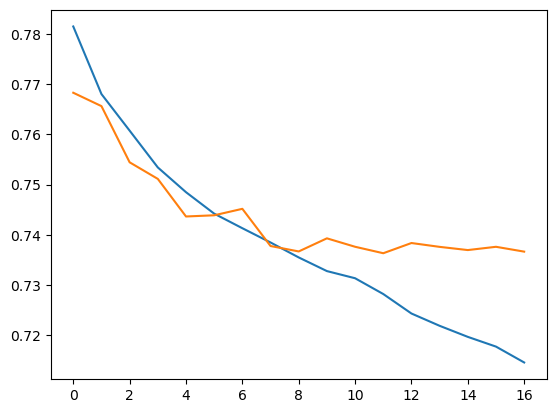

In [10]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")



# Use of AI and Web Resources
* Gathered scaffolding and block functions from lecture notes from CS425 and CS445. Used Claude Code to help update these functions for use with taking one-hot encoded DNA sequences as input to a transformer model with a CNN stem/backbone.